# Hiệu chỉnh ngưỡng và khoảng tin cậy bootstrap — CatBoost @ T=150

Hai phân tích bổ sung cho mô hình đã chọn (CatBoost, bộ 15 đặc trưng đầy đủ,
mốc dự đoán 150 ngày):

1. **Hiệu chỉnh ngưỡng phân loại** — ngưỡng mặc định 0.5 tối ưu cho F1, nhưng
   với bài toán cảnh báo sớm thì bỏ sót một sinh viên có nguy cơ tốn kém hơn
   một cảnh báo nhầm. Phần này định lượng cái giá phải trả khi hạ ngưỡng để
   bắt thêm sinh viên At-risk.
2. **Bootstrap trên tập kiểm tra** — mọi chỉ số trong báo cáo đều là ước lượng
   điểm trên một tập kiểm tra hữu hạn. Bootstrap cho biết các chỉ số đó dao
   động bao nhiêu, tức khoảng tin cậy 95%.

Kết quả được ghi ra `full_report/results_threshold_t150.json` để `gen_tables.py`
sinh bảng LaTeX, không chép tay số nào.

In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
)

TARGET_NAMES = ['Pass', 'At-risk']
CLASSES = [0, 1]
PREDICTION_POINT = 150
N_TRIALS = 30                 # giu nguyen nhu notebook goc de tai lap dung
N_BOOT   = 2000               # so lan lay mau bootstrap

FIG_DIR = Path('../full_report/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR = Path('../full_report')
REF = json.loads((RES_DIR / 'results_t150.json').read_text(encoding='utf-8'))
REF_CAT = REF['compare']['full']['CatBoost']
print('Chỉ số CatBoost trong báo cáo (bộ đầy đủ):', REF_CAT)

Chỉ số CatBoost trong báo cáo (bộ đầy đủ): {'accuracy': 0.8515, 'precision': 0.8039, 'recall': 0.7729, 'f1': 0.7881, 'roc_auc': 0.9126}


## 1. Dữ liệu

In [2]:
data_dir = Path('../data/processed')
X_tr_all = pd.read_parquet(data_dir / 'X_train.parquet')
X_te_all = pd.read_parquet(data_dir / 'X_test.parquet')
y_tr_all = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_te_all = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
m_tr = pd.read_parquet(data_dir / 'train_meta.parquet')
m_te = pd.read_parquet(data_dir / 'test_meta.parquet')

sel_tr = (m_tr['prediction_point'] == PREDICTION_POINT).values
sel_te = (m_te['prediction_point'] == PREDICTION_POINT).values
LABEL_MAP = {0: 1, 1: 0, 2: 1}

X_train = X_tr_all[sel_tr].reset_index(drop=True).fillna(0)
X_test  = X_te_all[sel_te].reset_index(drop=True).fillna(0)
y_train = y_tr_all[sel_tr].reset_index(drop=True).map(LABEL_MAP)
y_test  = y_te_all[sel_te].reset_index(drop=True).map(LABEL_MAP)

n_at_risk = int((y_test == 1).sum())
print(f'Train {X_train.shape} | Test {X_test.shape} | At-risk trong test: {n_at_risk:,}')

Train (17386, 15) | Test (4363, 15) | At-risk trong test: 1,559


## 2. Dựng lại đúng mô hình CatBoost của báo cáo

`results_t150.json` lưu `smote_ratio` và `w_at_risk` đã làm tròn 2 chữ số, nên
không đủ để tái tạo mô hình y hệt. Vì study Optuna là **tất định** (cùng seed,
cùng không gian tìm kiếm, cùng dữ liệu), chạy lại study của riêng CatBoost sẽ
cho lại đúng bộ siêu tham số gốc ở đầy đủ độ chính xác.

Kết quả được lưu vào `catboost_exact_params.json`; lần chạy sau sẽ nạp thẳng
từ file này thay vì tinh chỉnh lại.

In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
CACHE = Path('catboost_exact_params.json')


def smote_resample(X, y, ratio):
    n_pos = int((np.asarray(y) == 1).sum())
    sm = SMOTE(sampling_strategy={1: int((1 + ratio) * n_pos)},
               random_state=RANDOM_SEED, k_neighbors=5)
    return sm.fit_resample(np.asarray(X), np.asarray(y))


def make_cat(params, w):
    return CatBoostClassifier(**params, class_weights=[1.0, w],
                              random_state=RANDOM_SEED, verbose=0)


if CACHE.exists():
    best = json.loads(CACHE.read_text(encoding='utf-8'))
    print('Nạp siêu tham số từ cache:', CACHE)
else:
    Xtr, ytr = np.asarray(X_train), np.asarray(y_train)

    def objective(trial):
        params = {
            'iterations':    trial.suggest_int('iterations', 200, 600),
            'depth':         trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        }
        ratio = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w     = trial.suggest_float('w_at_risk', 1.0, 8.0)
        scores = []
        for i_tr, i_val in cv.split(Xtr, ytr):
            Xf, yf = smote_resample(Xtr[i_tr], ytr[i_tr], ratio)
            m = make_cat(params, w)
            m.fit(Xf, yf)
            scores.append(f1_score(ytr[i_val], m.predict(Xtr[i_val]),
                                   pos_label=1, zero_division=0))
        return float(np.mean(scores))

    t0 = time.time()
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    bp = dict(study.best_params)
    best = {
        'model_params': {k: v for k, v in bp.items()
                         if k not in ('smote_ratio_at_risk', 'w_at_risk')},
        'smote_ratio': bp['smote_ratio_at_risk'],
        'w_at_risk':   bp['w_at_risk'],
        'cv_f1':       float(study.best_value),
    }
    CACHE.write_text(json.dumps(best, indent=2), encoding='utf-8')
    print(f'Tinh chỉnh xong trong {time.time()-t0:.0f}s -> đã lưu {CACHE}')

print('SMOTE ratio (đủ độ chính xác):', best['smote_ratio'])
print('Trọng số At-risk :', best['w_at_risk'])

Nạp siêu tham số từ cache: catboost_exact_params.json
SMOTE ratio (đủ độ chính xác): 0.573931655089634
Trọng số At-risk : 1.325152889039984


In [4]:
X_sm, y_sm = smote_resample(X_train, y_train, best['smote_ratio'])
model = make_cat(best['model_params'], best['w_at_risk'])
model.fit(X_sm, y_sm)

proba = model.predict_proba(np.asarray(X_test))[:, 1]
y_true = np.asarray(y_test)


def metrics_at(thr, p=None, yt=None):
    p = proba if p is None else p
    yt = y_true if yt is None else yt
    y_pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, y_pred, labels=CLASSES).ravel()
    return {
        'accuracy':  accuracy_score(yt, y_pred),
        'precision': precision_score(yt, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(yt, y_pred, pos_label=1, zero_division=0),
        'f1':        f1_score(yt, y_pred, pos_label=1, zero_division=0),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }


base = metrics_at(0.5)
base['roc_auc'] = roc_auc_score(y_true, proba)

print('--- Ngưỡng 0.5: notebook vs báo cáo ---')
ok = True
for k in ('accuracy', 'precision', 'recall', 'f1', 'roc_auc'):
    got, exp = round(base[k], 4), REF_CAT[k]
    flag = 'KHỚP' if got == exp else 'LỆCH'
    ok &= (got == exp)
    print(f'  {k:10s} notebook={got:.4f}  báo cáo={exp:.4f}  -> {flag}')
assert ok, 'Không tái lập được mô hình gốc — dừng lại, không dùng số liệu này.'
print('\n=> Tái lập chính xác mô hình của báo cáo.')

--- Ngưỡng 0.5: notebook vs báo cáo ---
  accuracy   notebook=0.8515  báo cáo=0.8515  -> KHỚP
  precision  notebook=0.8039  báo cáo=0.8039  -> KHỚP
  recall     notebook=0.7729  báo cáo=0.7729  -> KHỚP
  f1         notebook=0.7881  báo cáo=0.7881  -> KHỚP
  roc_auc    notebook=0.9126  báo cáo=0.9126  -> KHỚP

=> Tái lập chính xác mô hình của báo cáo.


## 3. Quét ngưỡng phân loại

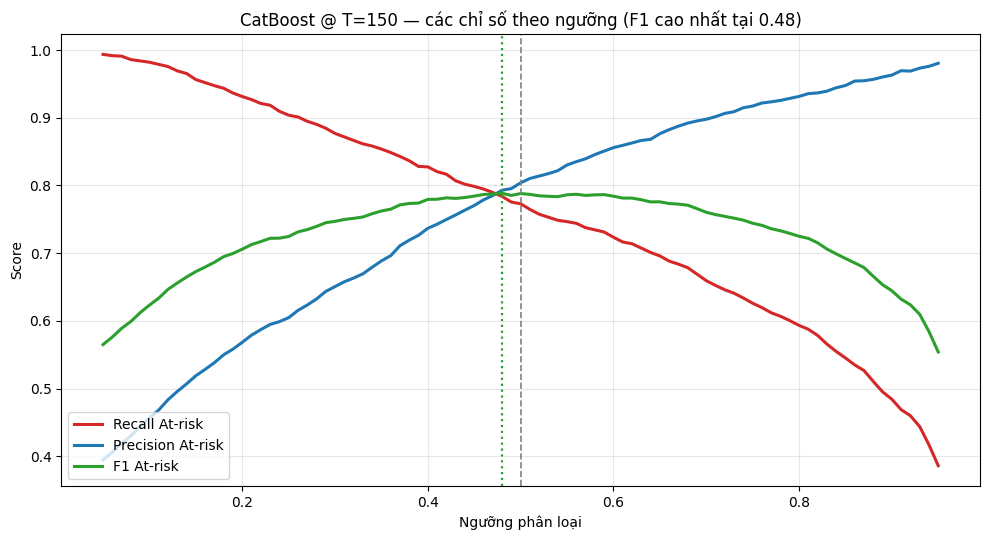

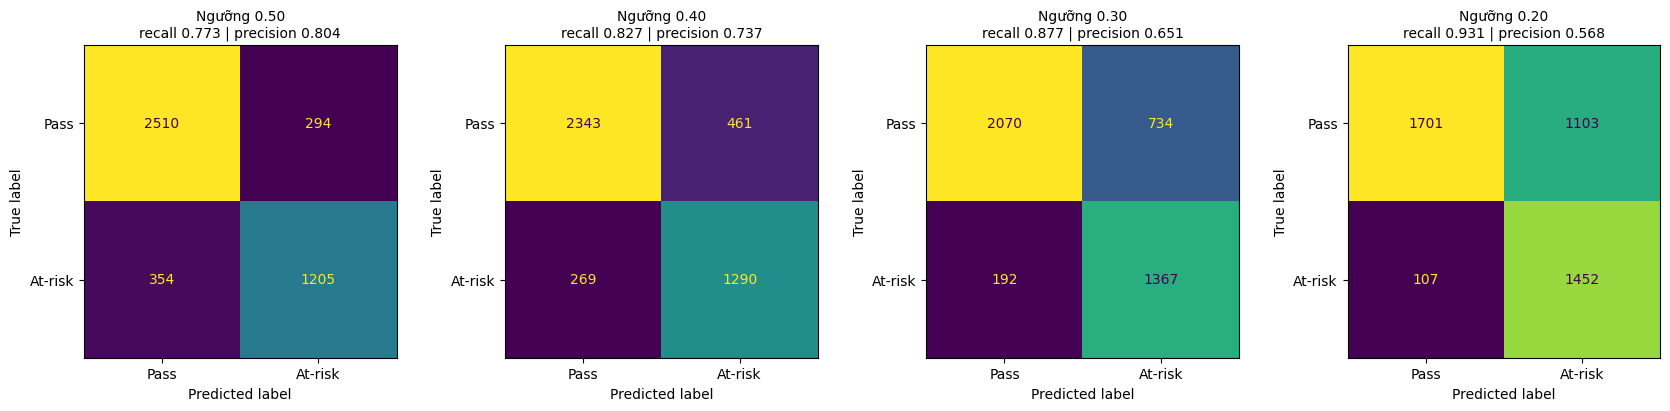

Tổng At-risk thực tế: 1,559

 threshold  recall  precision     f1   TP  FN   FP
       0.5  0.7729     0.8039 0.7881 1205 354  294
       0.4  0.8275     0.7367 0.7795 1290 269  461
       0.3  0.8768     0.6506 0.7470 1367 192  734
       0.2  0.9314     0.5683 0.7059 1452 107 1103


In [5]:
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
sweep = pd.DataFrame([metrics_at(t) for t in thresholds], index=thresholds)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(thresholds, sweep['recall'],    linewidth=2.2, color='tab:red',   label='Recall At-risk')
ax.plot(thresholds, sweep['precision'], linewidth=2.2, color='tab:blue',  label='Precision At-risk')
ax.plot(thresholds, sweep['f1'],        linewidth=2.2, color='tab:green', label='F1 At-risk')
ax.axvline(0.5, linestyle='--', color='gray', linewidth=1.2)
ax.annotate('Ngưỡng mặc định 0.5', xy=(0.5, 0.05), xytext=(0.55, 0.08), fontsize=9, color='gray')
t_best = float(sweep['f1'].idxmax())
ax.axvline(t_best, linestyle=':', color='tab:green', linewidth=1.6)
ax.set_xlabel('Ngưỡng phân loại'); ax.set_ylabel('Score')
ax.set_title(f'CatBoost @ T=150 — các chỉ số theo ngưỡng (F1 cao nhất tại {t_best:.2f})')
ax.grid(alpha=0.3); ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

SHOW = [0.5, 0.4, 0.3, 0.2]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, t in zip(axes, SHOW):
    m = metrics_at(t)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(
        ax=ax, colorbar=False, cmap='viridis')
    ax.set_title(f"Ngưỡng {t:.2f}\nrecall {m['recall']:.3f} | precision {m['precision']:.3f}",
                 fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cm_by_threshold.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

rows = []
for t in SHOW:
    m = metrics_at(t)
    rows.append({'threshold': t, 'recall': round(m['recall'], 4),
                 'precision': round(m['precision'], 4), 'f1': round(m['f1'], 4),
                 'TP': m['TP'], 'FN': m['FN'], 'FP': m['FP']})
thr_table = pd.DataFrame(rows)
print(f'Tổng At-risk thực tế: {n_at_risk:,}\n')
print(thr_table.to_string(index=False))

## 4. Ngưỡng cần dùng để đạt recall mục tiêu, và chi phí biên

In [6]:
TARGETS = [0.80, 0.85, 0.90, 0.95]
fine = np.round(np.arange(0.01, 1.00, 0.005), 3)
recalls_fine = {t: recall_score(y_true, (proba >= t).astype(int),
                                pos_label=1, zero_division=0) for t in fine}

target_rows = []
for tgt in TARGETS:
    cand = [t for t in fine if recalls_fine[t] >= tgt]
    if not cand:
        continue
    t = max(cand)                       # nguong cao nhat dat duoc muc tieu
    m = metrics_at(t)
    target_rows.append({
        'target':      tgt,
        'threshold':   float(t),
        'recall':      round(m['recall'], 4),
        'precision':   round(m['precision'], 4),
        'extra_TP':    m['TP'] - base['TP'],
        'extra_FP':    m['FP'] - base['FP'],
        'FN':          m['FN'],
        'cost':        round((m['FP'] - base['FP']) / (m['TP'] - base['TP']), 2)
                       if m['TP'] > base['TP'] else None,
    })
target_table = pd.DataFrame(target_rows)
print(f"Mốc gốc (ngưỡng 0.5): bắt {base['TP']}, bỏ sót {base['FN']}, nhầm {base['FP']}\n")
print(target_table.to_string(index=False))

seg_rows = []
for hi, lo in [(0.5, 0.4), (0.4, 0.3), (0.3, 0.2), (0.2, 0.1)]:
    a, b = metrics_at(hi), metrics_at(lo)
    dtp, dfp = b['TP'] - a['TP'], b['FP'] - a['FP']
    seg_rows.append({'from': hi, 'to': lo, 'extra_TP': dtp, 'extra_FP': dfp,
                     'cost': round(dfp / dtp, 2) if dtp else None})
seg_table = pd.DataFrame(seg_rows)
print('\nChi phí biên theo từng khoảng hạ ngưỡng:')
print(seg_table.to_string(index=False))

Mốc gốc (ngưỡng 0.5): bắt 1205, bỏ sót 354, nhầm 294

 target  threshold  recall  precision  extra_TP  extra_FP  FN  cost
   0.80      0.440  0.8018     0.7636        45        93 309  2.07
   0.85      0.355  0.8531     0.6942       125       292 229  2.34
   0.90      0.260  0.9012     0.6154       200       584 154  2.92
   0.95      0.165  0.9506     0.5342       277       998  77  3.60

Chi phí biên theo từng khoảng hạ ngưỡng:
 from  to  extra_TP  extra_FP  cost
  0.5 0.4        85       167  1.96
  0.4 0.3        77       273  3.55
  0.3 0.2        85       369  4.34
  0.2 0.1        79       720  9.11


## 5. Bootstrap — khoảng tin cậy 95% của các chỉ số

Lấy mẫu lại tập kiểm tra **có hoàn lại** (cùng kích thước, $B = 2000$ lần), mỗi
lần tính lại toàn bộ chỉ số. Khoảng tin cậy 95% lấy theo phân vị 2.5% và 97.5%
của phân phối bootstrap. Cách này phản ánh mức dao động của chỉ số do tập kiểm
tra chỉ là một mẫu hữu hạn.

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
n = len(y_true)
METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

boot = {m: [] for m in METRICS}
t0 = time.time()
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    yt, pp = y_true[idx], proba[idx]
    if yt.sum() == 0 or yt.sum() == len(yt):
        continue
    m = metrics_at(0.5, p=pp, yt=yt)
    for k in METRICS[:4]:
        boot[k].append(m[k])
    boot['roc_auc'].append(roc_auc_score(yt, pp))
print(f'{N_BOOT} lần bootstrap trong {time.time()-t0:.0f}s')

ci_rows = []
for k in METRICS:
    arr = np.array(boot[k])
    lo, hi = np.percentile(arr, [2.5, 97.5])
    ci_rows.append({'metric': k, 'point': round(base[k], 4),
                    'boot_mean': round(arr.mean(), 4), 'ci_low': round(lo, 4),
                    'ci_high': round(hi, 4), 'width': round(hi - lo, 4),
                    'se': round(arr.std(ddof=1), 4)})
ci_table = pd.DataFrame(ci_rows)
print()
print(ci_table.to_string(index=False))

2000 lần bootstrap trong 36s

   metric  point  boot_mean  ci_low  ci_high  width     se
 accuracy 0.8515     0.8515  0.8414   0.8625 0.0211 0.0054
precision 0.8039     0.8040  0.7839   0.8239 0.0399 0.0105
   recall 0.7729     0.7729  0.7525   0.7949 0.0424 0.0108
       f1 0.7881     0.7881  0.7720   0.8049 0.0329 0.0082
  roc_auc 0.9126     0.9126  0.9033   0.9215 0.0183 0.0046


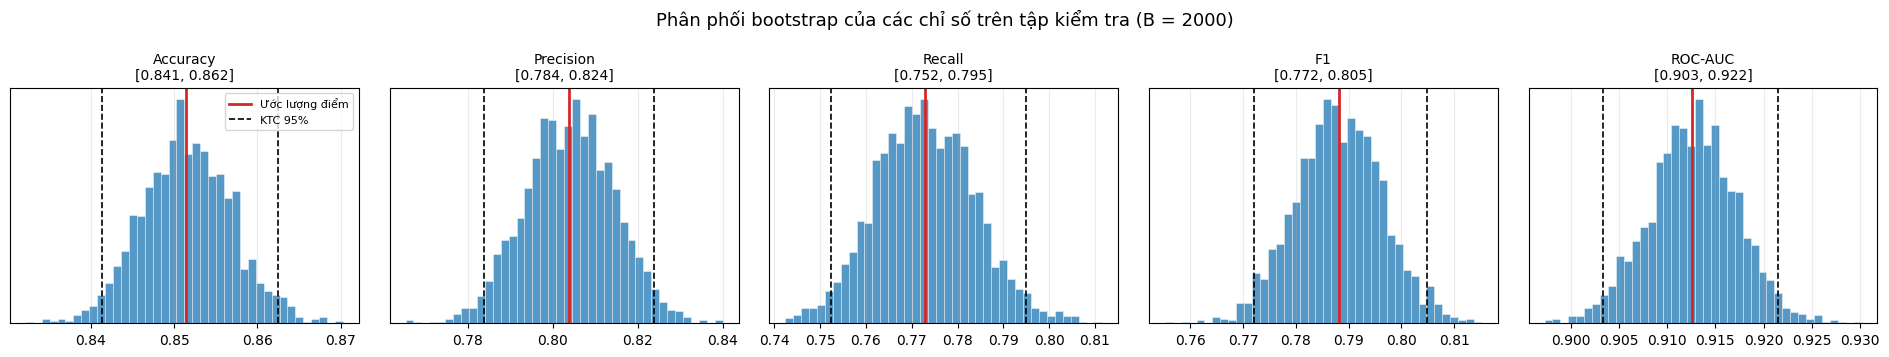

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
LABELS = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall',
          'f1': 'F1', 'roc_auc': 'ROC-AUC'}
for ax, k in zip(axes, METRICS):
    arr = np.array(boot[k])
    lo, hi = np.percentile(arr, [2.5, 97.5])
    ax.hist(arr, bins=40, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(base[k], color='tab:red', linewidth=2, label='Ước lượng điểm')
    ax.axvline(lo, color='k', linestyle='--', linewidth=1.2)
    ax.axvline(hi, color='k', linestyle='--', linewidth=1.2, label='KTC 95%')
    ax.set_title(f'{LABELS[k]}\n[{lo:.3f}, {hi:.3f}]', fontsize=10)
    ax.set_yticks([]); ax.grid(alpha=0.25, axis='x')
axes[0].legend(fontsize=8)
plt.suptitle('Phân phối bootstrap của các chỉ số trên tập kiểm tra (B = 2000)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

## 6. Xuất kết quả ra JSON

In [9]:
out = {
    'prediction_point': PREDICTION_POINT,
    'model': 'CatBoost',
    'feature_set': 'Full (15)',
    'n_test': int(n), 'n_at_risk_test': n_at_risk,
    'n_boot': N_BOOT,
    'baseline_threshold': 0.5,
    'baseline': {k: round(base[k], 4) for k in METRICS} |
                {k: base[k] for k in ('TP', 'FP', 'FN', 'TN')},
    'threshold_table': thr_table.to_dict(orient='records'),
    'target_recall':   target_table.to_dict(orient='records'),
    'marginal_cost':   seg_table.to_dict(orient='records'),
    'bootstrap_ci':    ci_table.to_dict(orient='records'),
    'best_f1_threshold': t_best,
}
p = RES_DIR / 'results_threshold_t150.json'
p.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding='utf-8')
print('Wrote', p.resolve())

Wrote D:\My Stuff\VinGroup Course\Internship VSF\early-academic-risk-warning\full_report\results_threshold_t150.json
